In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
import time
import math
import datetime
import warnings
from operator import itemgetter
from pathlib import Path

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2
from torch.utils.data import DataLoader, default_collate

import sys
sys.path.append('../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.torch_video.utils.plotting import plot_all
from computer_vision.torch_video.utils.progress import MetricLogger, SmoothedValue, form_stats, save_metrics
from computer_vision.torch_video.utils.metrics import accuracy
from computer_vision.torch_video.utils.torch_utils import reduce_across_processes, initialize_weights, seed_worker, save_checkpoint, clear_memory, init_seeds,\
init_distributed_mode, load_checkpoint
from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW, DATA_MEAN, DATA_STD, NUM_CLASSES
from computer_vision.torch_video.data.sampler import RandomClipSampler, UniformClipSampler

from computer_vision.torch_video.parameter_parser import parser

from computer_vision.slowfast.model.recognizer3d import Recognizer3D
from computer_vision.slowfast.model.config import backbone, cls_head

In [3]:
output_dirpath='D:/results/ucf101'
checkpoint_fpath=f'{output_dirpath}/mmaction2-slowfast/demo/slowfast_r50_8xb8-4x16x1-256e_kinetics400.pth' # actually slowfast_r50_8xb8-4x16x1-256e_kinetics400-rgb_20220901-701b0f6f.pth
video_file=f'{output_dirpath}/demo.mp4'
label_file=f'{output_dirpath}/label_map_k400.txt '
use_standard_normalize=True
n_video=1

labels = open(label_file).readlines()
labels = [x.strip() for x in labels]
print(f"{len(labels)}, {labels[:10]}")

model=Recognizer3D(backbone=backbone, cls_head=cls_head)

orig_checkpoint=torch.load(checkpoint_fpath, map_location='cpu', weights_only=False)
print(f"{orig_checkpoint.keys()=}")
model.load_state_dict(orig_checkpoint['state_dict'])
model.eval()

400, ['abseiling', 'air drumming', 'answering questions', 'applauding', 'applying cream', 'archery', 'arm wrestling', 'arranging flowers', 'assembling computer', 'auctioning']
In resnet3d_slowfast.ResNet3dSlowFast.__init__ slow_pathway={'type': 'resnet3d', 'depth': 50, 'pretrained': None, 'lateral': True, 'conv1_kernel': (1, 7, 7), 'dilations': (1, 1, 1, 1), 'conv1_stride_t': 1, 'pool1_stride_t': 1, 'inflate': (0, 0, 1, 1), 'norm_eval': False, 'speed_ratio': 8, 'channel_ratio': 8} 
In resnet3d_slowfast.ResNet3dSlowFast.__init__ fast_pathway={'type': 'resnet3d', 'depth': 50, 'pretrained': None, 'lateral': False, 'base_channels': 8, 'conv1_kernel': (5, 7, 7), 'conv1_stride_t': 1, 'pool1_stride_t': 1, 'norm_eval': False} 
In ResNet3dPathway._calculate_lateral_inplanes: depth=50, expansion=4, base_channels=64
stage 0 ----------
	planes=64, self.lateral=True, self.lateral_activate[i]=1, self.lateral_inv=False
stage 1 ----------
	planes=256, self.lateral=True, self.lateral_activate[i]=1, sel

Recognizer3D(
  (backbone): ResNet3dSlowFast(
    (slow_path): ResNet3dPathway(
      (conv1): ConvModule(
        (conv): Conv3d(3, 64, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU(inplace=True)
      )
      (max_pool): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
      (pool2): MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1), padding=0, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck3d(
          (conv1): ConvModule(
            (conv): Conv3d(80, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
            (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (activation): ReLU(inplace=True)
          )
          (conv2): ConvModule(
            (conv): Conv3d(64, 64, kernel_size=(1, 3, 3), stride=

In [4]:
from computer_vision.mm_slowfast.mmaction.datasets.transforms.loading import DecordInit, SampleFrames, DecordDecode
from computer_vision.mm_slowfast.mmaction.datasets.transforms.processing import Resize, RandomCrop, CenterCrop, ThreeCrop, RandomResizedCrop, Flip
from computer_vision.mm_slowfast.mmaction.datasets.transforms.formatting import FormatShape, PackActionInputs
# from computer_vision.mm_slowfast.mmengine.dataset.base_dataset import Compose
# from computer_vision.mm_slowfast.mmengine.dataset.utils import pseudo_collate


data=dict(filename=video_file, label=-1, start_index=0, modality='RGB')
print(f"{data=}")

# from cfg.test_pipeline
transforms=[DecordInit(io_backend='disk'),
            SampleFrames(clip_len=32, frame_interval=2, num_clips=10, test_mode=True),
            DecordDecode(),
            Resize(scale=(-1, 256), keep_ratio=True, interpolation='bilinear', lazy=False),
            RandomResizedCrop(),
            Resize(scale=(224, 224), keep_ratio=False, interpolation='bilinear', lazy=False),
            Flip(flip_ratio=1.),
            FormatShape(input_format='NCTHW'),
            PackActionInputs()]
inputs=None
for i, transform in enumerate(transforms):inputs=transform(data)
print(f"{type(inputs)=}, {len(inputs)=}, {inputs.keys()=}, {inputs['inputs'].shape}")
inputs=inputs['inputs']

data={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB'}
type(inputs)=<class 'dict'>, len(inputs)=2, inputs.keys()=dict_keys(['inputs', 'data_samples']), torch.Size([10, 3, 32, 224, 224])


inputs.shape=torch.Size([10, 3, 32, 224, 224]), torch.uint8
sampled_imgs.shape=torch.Size([32, 3, 224, 224])


(np.float64(-0.5), np.float64(1809.5), np.float64(905.5), np.float64(-0.5))

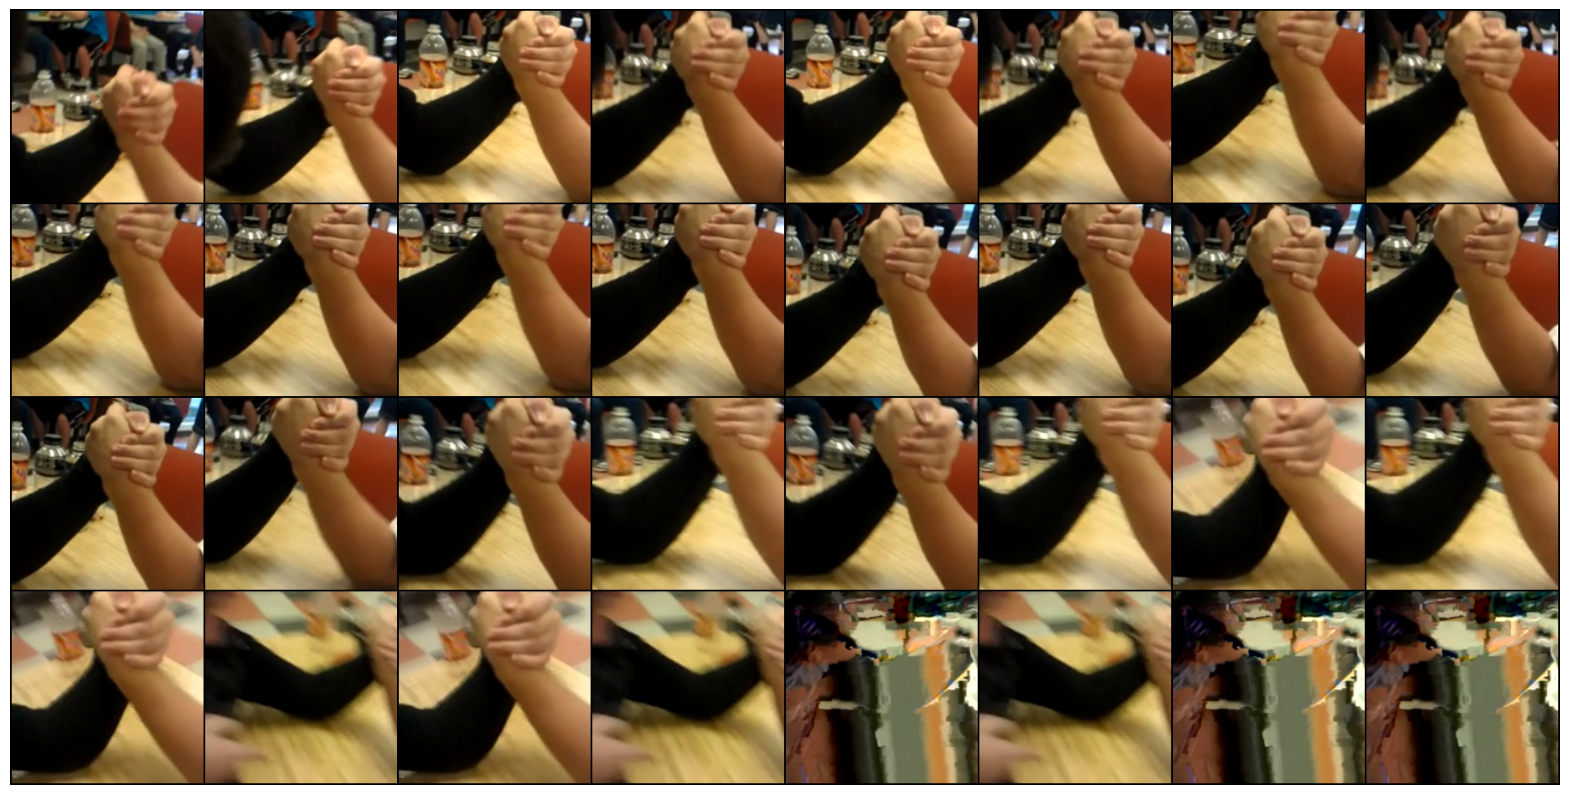

In [5]:
n_clips,C,T,H,W=inputs.shape
print(f"{inputs.shape=}, {inputs.dtype}")
# from (n_clips,C,T,H,W) to (n_clips,T,C,H,W) to (n_clips*T,C,H,W)
sampled_imgs=inputs.permute(0,2,1,3,4).reshape(-1,C,H,W)[::10]  
print(f"{sampled_imgs.shape=}")

_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(sampled_imgs, nrow=8).permute(1,2,0))
ax.axis("off")

In [6]:

if use_standard_normalize:
    inputs=inputs.float()
    mean=torch.tensor([123.675, 116.28, 103.53])[None,:,None,None,None]
    std=torch.tensor([58.395, 57.12, 57.375])[None:,None,None,None]
    inputs=(inputs-mean)/std # (n_clips, C, T, H, W)
else: inputs=inputs/255. # normalize video
print(f"{inputs.dtype=}, {inputs.min().item()=}, {inputs.max().item()=}")
with torch.no_grad(): outputs=model(inputs) # expect (N, num_crops, C, T, H, W) or (num_crops, C, T, H, W)
print(f"{type(outputs)=}, {outputs.shape=}")

# processing model outputs
num_segs=outputs.shape[0]//n_video
batch_size=outputs.shape[0]
outputs=outputs.view(batch_size//num_segs, num_segs, *outputs.shape[1:]) # (N, n_clips, n_classes) where N is the batch size, (1, 10,400) in this case
print(f"{outputs.shape=}") 
cls_scores=F.softmax(outputs, dim=-1).mean(dim=1) # average along num_clips dimension (N, n_classes), (1, 400) in this case
print(f"{cls_scores.shape=}")
pred_labels=cls_scores.argmax(dim=-1, keepdim=True).detach() # (B, 1)
print(f"{pred_labels.shape=}, {pred_labels=}")

# Because this is just 1 video 
pred_labels=pred_labels.squeeze(dim=0).item()
cls_scores=cls_scores.squeeze(dim=0).tolist()
score_tuples=tuple(zip(range(len(cls_scores)), cls_scores))
score_sorted=sorted(score_tuples, key=itemgetter(1), reverse=True) # sort score_tuples by score (second term) from large to small
top5_label=score_sorted[:5]
print(f"{top5_label=}")
results=[(labels[k[0]], k[1]) for k in top5_label]
print(f"{results=}")

inputs.dtype=torch.float32, inputs.min().item()=-2.1179039478302, inputs.max().item()=2.640000104904175
inputs.shape=torch.Size([10, 3, 32, 224, 224])
type(outputs)=<class 'torch.Tensor'>, outputs.shape=torch.Size([10, 400])
outputs.shape=torch.Size([1, 10, 400])
cls_scores.shape=torch.Size([1, 400])
pred_labels.shape=torch.Size([1, 1]), pred_labels=tensor([[6]])
top5_label=[(6, 0.9911717176437378), (108, 0.0007838723249733448), (345, 0.0005710569676011801), (203, 0.00043239296064712107), (150, 0.00042458795360289514)]
results=[('arm wrestling', 0.9911717176437378), ('dying hair', 0.0007838723249733448), ('sword fighting', 0.0005710569676011801), ('opening bottle', 0.00043239296064712107), ('headbutting', 0.00042458795360289514)]
